# Day 4 — Deep Learning Engineering

## Note 4.1 — Data You Can Trust

### How to read this note

This note answers one question:

> **How do I know that my validation score is telling me the truth?**

On Day 3 you trained a model and read its score. That score came from a set of rows called the validation set. The whole time, you were trusting one thing without checking it: that those rows are a fair stand-in for the data the model will meet after you ship it.

This note checks that trust. It uses the same Bank Marketing file you have used since Day 2, and it finds three ways the trust can break.

Everything is built in front of you. Every function is written in the notebook, run, and its output shown. Nothing is imported from a file you cannot see.

### Learning goal and outcome

**Goal:** Learn to inspect a dataset and a data split before training anything, so that the number you report at the end means what you think it means.

The shape of the work:

```text
raw file
   ↓
look at it (audit)
   ↓
split it (train / validation / test)
   ↓
fit the preprocessing on train only
   ↓
transform every part with that same fitted object
   ↓
now a score is meaningful
```

**Outcome:** by the end of this note, you should be able to:

- find the problems in a dataset that `isna()` cannot see;
- split a dataset four different ways and say what question each split answers;
- measure leakage instead of arguing about it;
- explain why a model that scores 0.78 on one split scores 0.61 on another, using the same rows;
- report a score for an imbalanced problem without fooling yourself.

### Objectives

By the end of this note you should be able to:

- explain what a train, validation and test set are for, in your own words;
- spot a **sentinel value**: a number that is secretly a flag, like `-1` meaning "never happened";
- write a small audit function and read its table;
- write a split function that supports four different splitting rules;
- write checks that stop the run when a split is broken;
- fit a scaler and an encoder on training rows only, and explain what goes wrong when you do not;
- discover that a file is in date order when it has no date column;
- measure how much a model's score drops when it is tested on a later time period;
- tell **label shift** from **covariate shift**;
- detect group leakage, where rows that belong together end up on both sides of a split;
- choose a decision threshold from a business limit instead of using 0.5.

### Dataset used

**UCI Bank Marketing (`bank-full.csv`).** 45,211 rows, 16 input columns and one label. A Portuguese bank phoned customers to offer a term deposit, and the label says whether the customer subscribed. It downloads from UCI with no account or key, and it is the same file you used on Day 2 and Day 3.

Why this file again, when the course usually changes datasets? Because the three problems this note is about are all really in it:

- the file is stored in **date order**, and the success rate climbs sharply from the start of the file to the end, which gives us real distribution shift;
- calls made on the same day share outcomes, which gives us a real group structure;
- only 11.7% of customers said yes, which gives us real class imbalance.

Using a file whose numbers you already know also means you can compare everything here with what you measured on Day 3.

**Model used:** logistic regression, from scikit-learn. It fits in about a second and gives the same answer every time. This note is about the data, so the simplest honest model keeps the attention there. The neural network comes back in Note 4.4.

### Table of contents

1. [What a split is pretending to be](#s1)
2. [Getting the data and looking at it](#s2)
3. [The problems `isna()` cannot see](#s3)
4. [Splitting on purpose](#s4)
5. [Preprocessing that belongs to the model](#s5)
6. [The clock hidden in the file](#s6)
7. [Two ways to split the same rows](#s7)
8. [What changed between the two periods](#s8)
9. [Group leakage: the calendar day](#s9)
10. [The 11.7% problem](#s10)
11. [Writing the decision down](#s11)

### Runtime budget

| Section | Approximate time |
|---|---|
| Downloading the data (first run only) | 20–60 s |
| Sections 1–5 | under 20 s combined |
| Section 7 — two logistic regressions | ~5 s |
| Section 8 — adversarial validation | ~25 s |
| Section 9 — twelve logistic regressions | ~35 s |
| Section 10 | ~5 s |

Total is about **two minutes** after the download. Everything runs on CPU. No GPU is needed anywhere in this note.

### Environment setup

The next cell imports everything the note uses and prints the versions. If you want to install the exact versions, uncomment the `pip` line.

In [1]:
# pip install torch==2.14.0 scikit-learn==1.8.0 numpy==2.4.4 pandas==3.0.2 matplotlib==3.10.8

import io
import os
import urllib.request
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)

SEED = 42          # one number that makes every random choice in this note repeatable

print("numpy      ", np.__version__)
print("pandas     ", pd.__version__)
print("torch      ", torch.__version__)

numpy       2.4.4
pandas      3.0.2
torch       2.14.0+cpu


Every notebook in this course starts by asking what hardware it is running on. A GPU makes big models faster. This note trains nothing big, so it does not need one, but the check stays because it is a habit worth having and because Note 4.3 depends on it.

- `torch.cuda.is_available()` is `True` on a machine with an NVIDIA GPU, which is what Colab and Kaggle give you.
- `torch.backends.mps.is_available()` is `True` on an Apple Silicon Mac (M1 to M5). MPS is Apple's name for its GPU backend.
- If neither is true, you are on CPU, which is fine here.

In [2]:
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    ACCELERATOR = torch.cuda.get_device_name(0)
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    ACCELERATOR = "Apple Silicon GPU (MPS)"
else:
    DEVICE = torch.device("cpu")
    ACCELERATOR = "none"

print(f"accelerator found : {ACCELERATOR}")
print(f"device            : {DEVICE}")
print("this note runs entirely on CPU, so the device above does not change any number here")

accelerator found : none
device            : cpu
this note runs entirely on CPU, so the device above does not change any number here


<a id="s1"></a>
## 1. What a split is pretending to be

Before any code, get one idea clear, because the rest of the note depends on it.

When you **split** a dataset, you cut the rows into groups and give each group a job:

- **training set** — the rows the model learns from;
- **validation set** — rows the model never learns from, used while you are still making choices (which learning rate, how many epochs, which model);
- **test set** — rows nobody touches until the very end, used once, to report a final number.

Now the important part. The test set has a part to play. It is **pretending to be the future**: the data your model will meet after you put it to work.

```text
the rows you have                        what they pretend to be

 ┌──────────────┐                         ┌──────────────┐
 │  training    │ ──────────────────────► │  the past    │
 └──────────────┘                         └──────────────┘
 ┌──────────────┐                         ┌──────────────┐
 │  test        │ ──────────────────────► │  the future  │
 └──────────────┘                         └──────────────┘
```

A split is good exactly as far as that pretending is convincing.

So the question to ask about any split is: **who, and when, will this model be used on?** For Bank Marketing the honest answer is: *customers the bank has not phoned yet, on days that have not happened yet.* Hold on to that sentence. Every section below tests one part of it.

You have already seen two ways this pretending fails, on Day 3:

- **Note 3.4, Case 4** put copies of training rows into the validation set. The validation score went to a perfect 1.0000. The split was pretending the future is the past.
- **Note 3.4, Case 6** kept a column called `duration`, the length of the phone call. You only know how long a call lasted after it has finished, so the model was reading something from the future. The score jumped to 0.9262 and meant nothing.

Both of those were deliberately obvious. Real ones are quieter, which is why this note measures rather than argues.

Let us make a split with ten rows, so you can see exactly what the words mean before we use 45,211 of them.

The tool is `train_test_split` from scikit-learn. It takes a list of things and cuts it in two. Its arguments:

- the first argument is what to cut, here the row numbers `0..9`;
- `train_size=0.6` means 60% goes to the first output, the rest to the second;
- `random_state=SEED` fixes the randomness, so you and I get the same cut;
- `shuffle=True` (the default) means it picks rows at random rather than cutting in the middle.

In [3]:
from sklearn.model_selection import train_test_split

toy_rows = np.arange(10)          # pretend row numbers 0 to 9
toy_train, toy_rest = train_test_split(toy_rows, train_size=0.6, random_state=SEED)

print("all rows      :", toy_rows)
print("train rows    :", np.sort(toy_train))
print("remaining rows:", np.sort(toy_rest))

all rows      : [0 1 2 3 4 5 6 7 8 9]
train rows    : [2 3 4 6 7 9]
remaining rows: [0 1 5 8]


Two things to notice, because both come back later.

First, the function gave back **row numbers**, not the data itself. That is deliberate and we will keep doing it: if you carry row numbers around, you can apply the same split to the features, to the labels and to anything else you calculate later, and they will always line up.

Second, the rows are picked at random, not in order. Rows 0, 1, 2 did not go together. That is the normal choice, and Section 7 shows where it goes wrong.

Now cut the remaining rows in two, to get the third group:

In [4]:
toy_val, toy_test = train_test_split(toy_rest, test_size=0.5, random_state=SEED)

print("train      :", np.sort(toy_train), f"  {len(toy_train)} rows")
print("validation :", np.sort(toy_val), f"  {len(toy_val)} rows")
print("test       :", np.sort(toy_test), f"  {len(toy_test)} rows")
print()
print("every row used once?", sorted(np.concatenate([toy_train, toy_val, toy_test])) == list(range(10)))

train      : [2 3 4 6 7 9]   6 rows
validation : [5 8]   2 rows
test       : [0 1]   2 rows

every row used once? True


That is the whole idea: cut once to get training, cut the leftovers again to get validation and test. Sixty percent, twenty, twenty. We will do exactly this to the real data in Section 4, with the same two calls.

<div align="center">

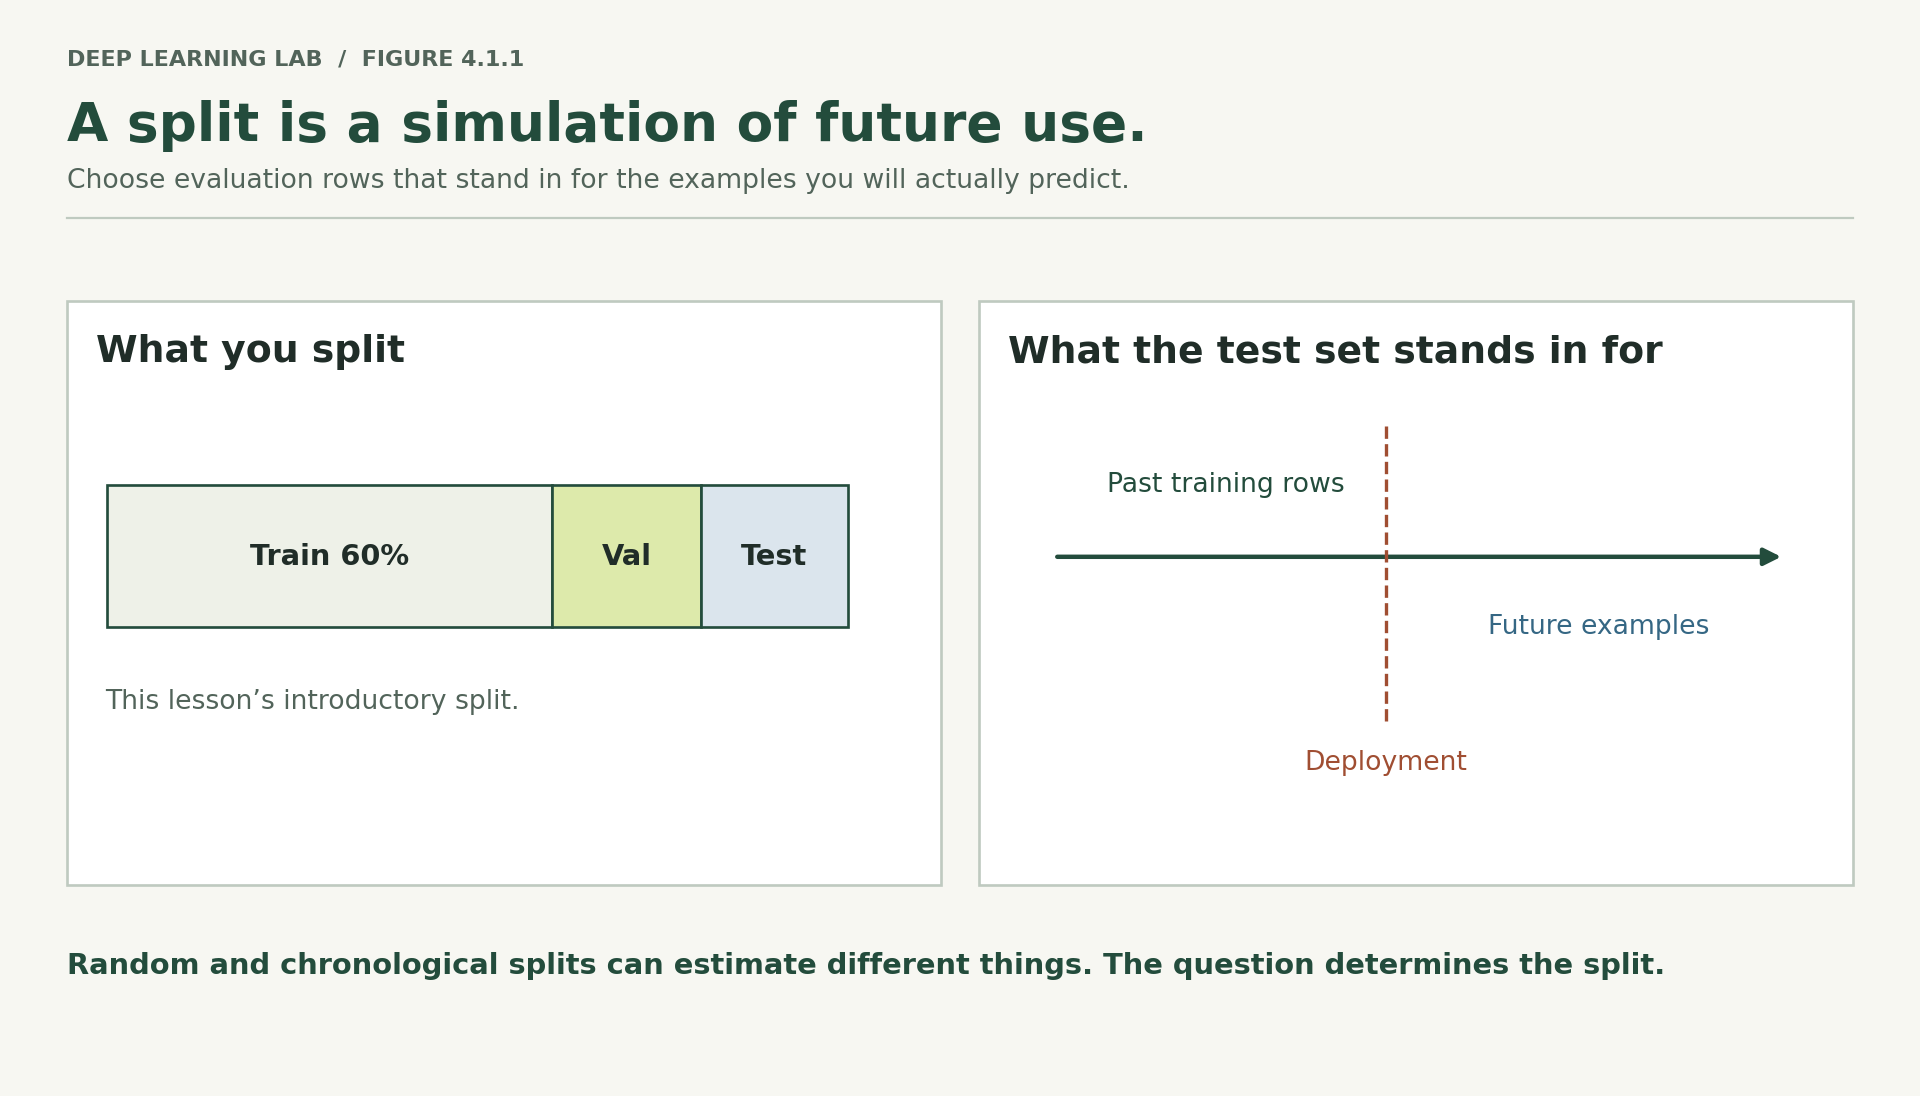

<p><b>Figure 4.1.1.</b> A 60/20/20 split is an introductory example. The crucial question is whether the held-out rows realistically represent deployment conditions.</p>

</div>

**Questions to sit with**

1. In your own words, what is the test set standing in for?
2. In Note 3.4 Case 4, no training diagnostic complained at all. Why can a broken split stay invisible to the loss curve?
3. Before reading on: is a random split a convincing stand-in for "customers not phoned yet, on days that have not happened yet"? What would have to be true about the file for it to be?

<a id="s2"></a>
## 2. Getting the data and looking at it

The next cell downloads the file if it is not already on disk. Reading it, line by line:

- `os.path.exists(path)` asks whether we already have the file, so a second run does not download again;
- `urllib.request.urlopen(url).read()` fetches the bytes from UCI;
- the download is a zip file with **another zip inside it**, so we open the outer one, pull `bank.zip` out of it, and open that to reach `bank-full.csv`;
- `io.BytesIO` lets `zipfile` treat those bytes as if they were a file on disk;
- `pd.read_csv(path, sep=";")` reads the CSV. The `sep=";"` matters: this file separates columns with semicolons, not commas. Without it you get one wide useless column.

In [5]:
BANK_URL = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"
BANK_CSV = "data/bank-full.csv"

def download_bank_marketing(path=BANK_CSV):
    """Download bank-full.csv from UCI if we do not already have it."""
    if os.path.exists(path):
        print(f"already here: {path}")
        return path
    print("downloading from UCI ...")
    raw_bytes = urllib.request.urlopen(BANK_URL, timeout=120).read()
    outer_zip = zipfile.ZipFile(io.BytesIO(raw_bytes))
    inner_zip = zipfile.ZipFile(io.BytesIO(outer_zip.read("bank.zip")))
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "wb") as f:
        f.write(inner_zip.read("bank-full.csv"))
    print(f"saved: {path}")
    return path

download_bank_marketing()
raw = pd.read_csv(BANK_CSV, sep=";")
print("rows and columns:", raw.shape)

already here: data/bank-full.csv
rows and columns: (45211, 17)


In [6]:
raw.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


The last column, `y`, is the label: `"yes"` if the customer subscribed to the term deposit, `"no"` otherwise. Everything else is an input.

Two words used throughout the course, in plain terms:

- a **numeric column** holds numbers you can do arithmetic with, like `age` or `balance`;
- a **categorical column** holds labels from a fixed set, like `job` or `month`. The numbers in them, if any, mean nothing arithmetically.

Let us see which is which, and how often each label says yes.

In [7]:
numeric_columns = raw.drop(columns="y").select_dtypes(include="number").columns.tolist()
categorical_columns = [c for c in raw.drop(columns="y").columns if c not in numeric_columns]

print("numeric     :", numeric_columns)
print("categorical :", categorical_columns)
print()
print(raw["y"].value_counts())
print()
print(f"share who said yes: {(raw['y'] == 'yes').mean():.4f}")

numeric     : ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
categorical : ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

y
no     39922
yes     5289
Name: count, dtype: int64

share who said yes: 0.1170


**11.7% said yes.** Write that number down; Section 10 is entirely about what it does to every score you report.

### One column has to go first

`duration` is the length of the phone call in seconds. Think about when you know it. You know it **after** the call has ended, which is also when you know the answer. A model using it is being told something that does not exist at the moment you would actually want a prediction.

This is called **target leakage**: an input column that carries information about the answer, information you would not have in real use.

Note 3.4 Case 6 measured it: keeping `duration` took validation AUC from 0.7853 to 0.9262. A jump like that looks like success and is worthless. Here is the reason it happens, in one line.

In [8]:
mean_duration_yes = raw.loc[raw["y"] == "yes", "duration"].mean()
mean_duration_no = raw.loc[raw["y"] == "no", "duration"].mean()

print(f"average call length when the answer was yes : {mean_duration_yes:6.1f} seconds")
print(f"average call length when the answer was no  : {mean_duration_no:6.1f} seconds")
print(f"ratio                                       : {mean_duration_yes / mean_duration_no:.1f}x")
print()
print("A long call means the customer was listening, which means they were likely to say yes.")
print("You cannot know the call length before the call, so the column has to go.")

average call length when the answer was yes :  537.3 seconds
average call length when the answer was no  :  221.2 seconds
ratio                                       : 2.4x

A long call means the customer was listening, which means they were likely to say yes.
You cannot know the call length before the call, so the column has to go.


In [9]:
data = raw.drop(columns="duration")
print("columns kept:", data.shape[1], "(15 inputs plus the label)")

columns kept: 16 (15 inputs plus the label)


**Questions to sit with**

1. `pdays` is the number of days since the customer was last contacted in a previous campaign. Is that target leakage? Why or why not?
2. A colleague adds a column `number_of_calls_made_to_this_customer_in_total`. What would you ask before allowing it?

<a id="s3"></a>
## 3. The problems `isna()` cannot see

The usual first check on a dataset is to count missing values. Run it here and the file looks perfect.

In [10]:
print("missing values per column:")
print(data.isna().sum().to_string())

missing values per column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
campaign     0
pdays        0
previous     0
poutcome     0
y            0


Zero everywhere. That is not the same as clean.

Missing information often arrives **disguised as a valid value**. Two disguises are extremely common:

- a **sentinel value**: a number chosen to mean "this did not happen". `-1`, `999` and `0` are the usual suspects;
- a **placeholder string**: a word like `"unknown"`, `"N/A"` or `"none"` sitting in a text column.

Neither is missing as far as pandas is concerned. Both are missing as far as meaning is concerned. Look for them by hand first, then we will wrap the search into a function.

In [11]:
print(data["pdays"].value_counts().head())

pdays
-1      36954
 182      167
 92       147
 91       126
 183      126
Name: count, dtype: int64


The value `-1` appears 36,954 times out of 45,211. `pdays` means "days since the customer was last contacted in a previous campaign", and `-1` is how this file says **never contacted before**.

So a yes/no fact is hiding inside a number column. That matters for two reasons. A scaler will treat `-1` as "one day before zero days ago", which is nonsense. And a model has to waste effort learning that this one value means something completely different from the others.

In [12]:
never_contacted = data["pdays"] == -1
print(f"share of rows with pdays == -1 : {never_contacted.mean():.3f}")
print()
print(data["poutcome"].value_counts())

share of rows with pdays == -1 : 0.817

poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64


`poutcome` is the outcome of the previous campaign, and it says `"unknown"` on almost exactly the same share of rows. That is suspicious in a useful way: two columns may be recording the same fact. Check whether they are the same rows.

In [13]:
poutcome_unknown = data["poutcome"] == "unknown"

print(f"pdays == -1                       : {never_contacted.mean():.3f}")
print(f"poutcome == 'unknown'             : {poutcome_unknown.mean():.3f}")
print(f"both at the same time             : {(never_contacted & poutcome_unknown).mean():.3f}")
print(f"poutcome unknown but pdays is set : {(poutcome_unknown & ~never_contacted).sum()} rows")

pdays == -1                       : 0.817
poutcome == 'unknown'             : 0.817
both at the same time             : 0.817
poutcome unknown but pdays is set : 5 rows


Same fact, written twice, apart from 5 rows. "We have never spoken to this person before."

Now the third column with a placeholder, `contact`, which records how the customer was reached. It says `"unknown"` on a lot of rows. Before deciding what to do with a placeholder, always check it against the label.

In [14]:
contact_summary = data.assign(subscribed=(data["y"] == "yes")).groupby("contact")["subscribed"].agg(["size", "mean"])
contact_summary.columns = ["rows", "share who said yes"]
print(contact_summary.round(4).to_string())

            rows  share who said yes
contact                             
cellular   29285              0.1492
telephone   2906              0.1342
unknown    13020              0.0407


This is the reason you check. `"unknown"` is not noise here. Those customers said yes 4.1% of the time, against 14.9% for customers reached on a mobile. The word is telling us something about how the bank was running that part of the campaign, and it predicts the answer.

So the right treatment is to **keep `"unknown"` as its own category**, not to replace it with the most common value. Replacing it would throw away a real signal. (Section 8 finds another reason to care about this column.)

### Wrapping the search into a function

We have now done the same few checks by hand three times. That is the moment to write a function. Ours takes a table and returns one row per column, with:

- `kind` — numeric or categorical;
- `n_unique` — how many different values appear;
- `missing` — the share that pandas calls missing;
- `unknown` — the share equal to the string `"unknown"`;
- `sentinel` — the share equal to a sentinel value we name ourselves;
- `negative` — the share below zero, for numeric columns;
- `top_value` and `top_share` — the commonest value and how much of the column it covers.

Two pieces of pandas used inside it:

- `pd.api.types.is_numeric_dtype(s)` answers "is this column numeric?";
- `s.value_counts(normalize=True)` counts each value and, with `normalize=True`, turns the counts into shares that add up to 1.

In [15]:
def audit(df, sentinels=None):
    """One row per column, describing what is actually in it."""
    sentinels = sentinels or {}          # e.g. {"pdays": -1}
    rows = []
    for column in df.columns:
        values = df[column]
        is_numeric = pd.api.types.is_numeric_dtype(values)
        shares = values.value_counts(normalize=True)
        rows.append({
            "column": column,
            "kind": "numeric" if is_numeric else "categorical",
            "n_unique": int(values.nunique()),
            "missing": float(values.isna().mean()),
            "unknown": 0.0 if is_numeric else float((values == "unknown").mean()),
            "sentinel": float((values == sentinels[column]).mean()) if column in sentinels else 0.0,
            "negative": float((values < 0).mean()) if is_numeric else 0.0,
            "top_value": shares.index[0],
            "top_share": float(shares.iloc[0]),
        })
    return pd.DataFrame(rows).set_index("column")

report = audit(data.drop(columns="y"), sentinels={"pdays": -1})
print(report.round(3).to_string())

                  kind  n_unique  missing  unknown  sentinel  negative    top_value  top_share
column                                                                                        
age            numeric        77      0.0    0.000     0.000     0.000           32      0.046
job        categorical        12      0.0    0.006     0.000     0.000  blue-collar      0.215
marital    categorical         3      0.0    0.000     0.000     0.000      married      0.602
education  categorical         4      0.0    0.041     0.000     0.000    secondary      0.513
default    categorical         2      0.0    0.000     0.000     0.000           no      0.982
balance        numeric      7168      0.0    0.000     0.000     0.083            0      0.078
housing    categorical         2      0.0    0.000     0.000     0.000          yes      0.556
loan       categorical         2      0.0    0.000     0.000     0.000           no      0.840
contact    categorical         3      0.0    0.288

Read down the table and three more things appear that we had not looked for.

- **`balance` is negative on 8.3% of rows.** For a bank balance that is an overdraft, so it is valid data. An audit raises questions; it does not pass verdicts.
- **`default` is one value on 98.2% of rows.** A column that says the same thing about nearly everybody can carry almost no information.
- **`pdays` is 81.7% negative**, which is the sentinel we already found, showing up from a second direction.

A table is easy to skim past, so it helps to turn it into sentences that demand an answer. The function below does that: it walks the audit table and prints a question for anything above a threshold.

In [16]:
def flag_issues(report, threshold=0.05):
    """Turn the audit table into questions somebody has to answer."""
    questions = []
    for column, row in report.iterrows():
        if row["missing"] > 0:
            questions.append(f"{column}: {row['missing']:.1%} missing")
        if row["unknown"] >= threshold:
            questions.append(f"{column}: {row['unknown']:.1%} say 'unknown' - a category, or missing data?")
        if row["sentinel"] >= threshold:
            questions.append(f"{column}: {row['sentinel']:.1%} are the sentinel value - a number, or a flag?")
        if row["negative"] >= threshold:
            questions.append(f"{column}: {row['negative']:.1%} are negative - is that valid here?")
        if row["top_share"] >= 0.95:
            questions.append(f"{column}: one value covers {row['top_share']:.1%} of rows - nearly constant")
    return questions

for question in flag_issues(report):
    print(" -", question)

 - default: one value covers 98.2% of rows - nearly constant
 - balance: 8.3% are negative - is that valid here?
 - contact: 28.8% say 'unknown' - a category, or missing data?
 - pdays: 81.7% are the sentinel value - a number, or a flag?
 - pdays: 81.7% are negative - is that valid here?
 - poutcome: 81.7% say 'unknown' - a category, or missing data?


### Duplicates

One more check before we split. A **duplicate** is a row that appears more than once. Duplicates matter for a reason that will not be obvious until Section 9: if the same row sits in training and in test, the model can score well by remembering rather than by learning.

Worth checking twice over:

- whole rows that repeat, label included;
- rows whose **inputs** repeat while their labels disagree, which means the data is telling you two different answers for the same situation.

In [17]:
inputs_only = data.drop(columns="y")

print("rows that repeat entirely      :", int(data.duplicated().sum()))
print("rows whose inputs repeat       :", int(inputs_only.duplicated().sum()))

rows that repeat entirely      : 16
rows whose inputs repeat       : 16


None at all, which is worth recording precisely because it is often not the case. Day 8 meets duplicates again in fine-tuning data, where they are common and cause real damage.

**Questions to sit with**

1. Why did we run the audit on the raw table instead of after encoding the columns into numbers?
2. `contact = "unknown"` predicts the label. Give one reason that could be a genuine signal, and one reason it could be a warning sign.
3. Pick a dataset from your own work. Which columns in it could contain a sentinel value, and what would the sentinel be?

**Try it.** Add a column `was_contacted_before = data["pdays"] != -1`, re-run `audit`, and then decide what you think should happen to `pdays` itself.

<a id="s4"></a>
## 4. Splitting on purpose

Now we split the real file, using the same two calls from Section 1. But this time we make the split a **choice we can name**, because there is more than one sensible way to do it.

Four rules, in plain words:

- **stratified** — pick rows at random, but keep the share of yes answers the same in every part;
- **random** — pick rows at random and let the shares fall where they may;
- **chronological** — the earliest rows for training, the middle for validation, the latest for test;
- **group** — decide which side a whole *group* of rows goes to, all together.

The first one is what Day 2 and Day 3 used. The rest arrive later in this note, each for a reason.

First, the target. We turn `"yes"`/`"no"` into `1.0`/`0.0` because every model in this course expects numbers.

In [18]:
X = data.drop(columns="y")                                  # the inputs
y = (data["y"] == "yes").astype(np.float32).to_numpy()      # the label as 1.0 / 0.0

print("inputs :", X.shape)
print("labels :", y.shape, "| first ten:", y[:10])
print("share of 1s:", round(float(y.mean()), 4))

inputs : (45211, 15)
labels : (45211,) | first ten: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
share of 1s: 0.117


### Stratified, by hand first

The word **stratified** means the split keeps the class balance. Our data is 11.7% yes. Without stratification, a random cut could hand the test set 10.4% and the training set 12.0% just by luck, and part of any difference you measure later would be that luck instead of your model.

`train_test_split` does it when you pass `stratify=y`. Watch it work on the real rows.

In [19]:
row_numbers = np.arange(len(y))

train_idx, rest_idx = train_test_split(row_numbers, train_size=0.8, random_state=SEED, stratify=y)
val_idx, test_idx = train_test_split(rest_idx, test_size=0.5, random_state=SEED, stratify=y[rest_idx])

print(f"train      : {len(train_idx):>6} rows | share yes {y[train_idx].mean():.4f}")
print(f"validation : {len(val_idx):>6} rows | share yes {y[val_idx].mean():.4f}")
print(f"test       : {len(test_idx):>6} rows | share yes {y[test_idx].mean():.4f}")
print(f"whole file : {len(y):>6} rows | share yes {y.mean():.4f}")

train      :  36168 rows | share yes 0.1170
validation :   4521 rows | share yes 0.1170
test       :   4522 rows | share yes 0.1170
whole file :  45211 rows | share yes 0.1170


All four shares agree to three decimals. That is stratification doing its job.

Note the second call passes `stratify=y[rest_idx]`, not `stratify=y`. It is splitting only the leftover rows, so it must be told the labels of *those* rows. Passing the whole label array there is a common and silent bug.

### The same thing, as a function

Now we collect the four rules into one function. It returns a **dictionary** with three keys, `"train"`, `"val"` and `"test"`, each holding an array of row numbers.

The pieces inside:

- `fractions=(0.8, 0.1, 0.1)` says how big each part should be;
- for `"chronological"` there is no randomness at all: we take the first 80% of rows in file order, then the next 10%, then the last 10%;
- for `"group"` we use `GroupShuffleSplit`, which keeps every row that shares a group label on the same side. Section 9 explains why that matters. Note that for this rule the fractions count *groups*, not rows;
- `int(round(...))` converts a fraction of the row count into a whole number of rows.

In [20]:
from sklearn.model_selection import GroupShuffleSplit

def make_split(y, policy="stratified", fractions=(0.8, 0.1, 0.1), seed=SEED, groups=None):
    """Return {'train', 'val', 'test'} -> row numbers, using one of four rules."""
    f_train, f_val, f_test = fractions
    n = len(y)
    row_numbers = np.arange(n)
    test_share_of_rest = f_test / (f_val + f_test)      # how much of the leftover is test

    if policy == "chronological":
        first_cut = int(round(f_train * n))
        second_cut = int(round((f_train + f_val) * n))
        return {"train": row_numbers[:first_cut],
                "val": row_numbers[first_cut:second_cut],
                "test": row_numbers[second_cut:]}

    if policy == "group":
        splitter = GroupShuffleSplit(n_splits=1, train_size=f_train, random_state=seed)
        train_pos, rest_pos = next(splitter.split(row_numbers, groups=groups))
        splitter2 = GroupShuffleSplit(n_splits=1, test_size=test_share_of_rest, random_state=seed)
        val_pos, test_pos = next(splitter2.split(rest_pos, groups=np.asarray(groups)[rest_pos]))
        return {"train": train_pos, "val": rest_pos[val_pos], "test": rest_pos[test_pos]}

    stratify_on = y if policy == "stratified" else None
    train, rest = train_test_split(row_numbers, train_size=f_train, random_state=seed, stratify=stratify_on)
    stratify_rest = y[rest] if policy == "stratified" else None
    val, test = train_test_split(rest, test_size=test_share_of_rest, random_state=seed, stratify=stratify_rest)
    return {"train": train, "val": val, "test": test}

split = make_split(y, "stratified", seed=SEED)
for part, rows in split.items():
    print(f"{part:<11} {len(rows):>6} rows | first five row numbers: {rows[:5]}")

train        36168 rows | first five row numbers: [24001 43409 20669 18810 23130]
val           4521 rows | first five row numbers: [29912 11683 29502 11078 40417]
test          4522 rows | first five row numbers: [44443 35157 39341 30761 32422]


Those are the same numbers we produced by hand a moment ago, which is the point: the function is not doing anything new, it is just giving the choice a name.

### Checks that stop the run

A split can be broken in ways that do not raise an error. Rows can land on two sides. Rows can vanish. A chronological split can quietly be out of order. So we write the checks down, and we use `assert`, which stops the notebook when the statement after it is false.

Each check in words:

- no row number appears in two parts (`&` on two Python sets gives what they share);
- the three parts add up to every row;
- for a chronological split, every training row comes before every validation row, which comes before every test row.

In [21]:
def check_split(split, y, policy="stratified"):
    """Stop the run if the split is broken, then summarise it."""
    train, val, test = split["train"], split["val"], split["test"]
    as_sets = [set(train), set(val), set(test)]

    assert not (as_sets[0] & as_sets[1]), "a row is in both train and validation"
    assert not (as_sets[0] & as_sets[2]), "a row is in both train and test"
    assert not (as_sets[1] & as_sets[2]), "a row is in both validation and test"
    assert len(train) + len(val) + len(test) == len(y), "rows were lost or duplicated"

    if policy == "chronological":
        assert train.max() < val.min(), "training rows are not all before validation rows"
        assert val.max() < test.min(), "validation rows are not all before test rows"

    return pd.DataFrame({part: {"rows": len(rows),
                                "share of file": round(len(rows) / len(y), 4),
                                "share who said yes": round(float(y[rows].mean()), 4)}
                         for part, rows in split.items()}).T

print(check_split(split, y, "stratified").to_string())

          rows  share of file  share who said yes
train  36168.0            0.8               0.117
val     4521.0            0.1               0.117
test    4522.0            0.1               0.117


Now break it on purpose, so you can see the check earn its place. We copy five training rows into the validation set, which is exactly the fault of Note 3.4 Case 4.

In [22]:
broken = {part: rows.copy() for part, rows in split.items()}
broken["val"] = np.concatenate([broken["val"], broken["train"][:5]])   # five rows now on both sides

try:
    check_split(broken, y, "stratified")
except AssertionError as error:
    print("the check stopped it:", error)

the check stopped it: a row is in both train and validation


Five rows out of 45,211 is a leak far too small to notice in any score, and the check caught it instantly. That is the trade: a few lines that run in a second, against a result you cannot trust.

**Questions to sit with**

1. Why does `make_split` hand back row numbers instead of three DataFrames?
2. The group rule splits by groups, not rows. When would that give you a test set much bigger or smaller than the 10% you asked for?
3. `check_split` uses `assert` instead of printing a warning. Why is stopping the better behaviour here?

<a id="s5"></a>
## 5. Preprocessing that belongs to the model

**Preprocessing** is everything done to the inputs between the raw table and the model: scaling numbers, turning categories into numbers, filling gaps. Two jobs in this note.

### Scaling, in plain arithmetic

Numeric columns here live on wildly different scales. `age` holds tens. `balance` holds thousands. A model that adds up inputs will feel `balance` far more strongly than `age`, for no better reason than the units.

Look at the actual ranges first.

In [23]:
print(X[["age", "balance", "campaign"]].agg(["min", "max"]).to_string())

     age  balance  campaign
min   18    -8019         1
max   95   102127        63


`balance` spans a range roughly ten thousand times wider than `age`. To a model that adds up its inputs, that difference alone makes `balance` shout and `age` whisper.

**Standardising** a column fixes that: subtract the column's average, then divide by its standard deviation. The result has average 0 and standard deviation 1. Do it by hand once, on five numbers.

In [24]:
small = np.array([10.0, 12.0, 14.0, 16.0, 18.0])
mean = small.mean()
std = small.std()

print("numbers        :", small)
print("average (mean) :", mean)
print("spread (std)   :", std)
print("standardised   :", (small - mean) / std)
print("new average    :", round(float(((small - mean) / std).mean()), 6))
print("new spread     :", round(float(((small - mean) / std).std()), 6))

numbers        : [10. 12. 14. 16. 18.]
average (mean) : 14.0
spread (std)   : 2.8284271247461903
standardised   : [-1.41421356 -0.70710678  0.          0.70710678  1.41421356]
new average    : 0.0
new spread     : 1.0


`StandardScaler` from scikit-learn does exactly that, one column at a time. Like most scikit-learn objects it has two methods that matter:

- `.fit(data)` — **learn** the numbers it needs, here each column's average and spread;
- `.transform(data)` — **apply** what it learned.

Keeping those two steps separate is the whole ballgame, as the rest of this section shows.

In [25]:
from sklearn.preprocessing import StandardScaler

scaler_demo = StandardScaler()
scaler_demo.fit(small.reshape(-1, 1))     # reshape because scikit-learn expects a 2-D table

print("learned average:", scaler_demo.mean_[0])
print("learned spread :", scaler_demo.scale_[0])
print("transformed    :", scaler_demo.transform(small.reshape(-1, 1)).ravel())

learned average:

 14.0
learned spread : 2.8284271247461903
transformed    : [-1.41421356 -0.70710678  0.          0.70710678  1.41421356]


### One-hot encoding, in plain arithmetic

A model cannot add up the word `"student"`. Categories have to become numbers, and the obvious idea is the wrong one. If you write `admin. = 0`, `blue-collar = 1`, `management = 2`, you have told the model that management is twice blue-collar and that admin is the smallest. None of that is true.

**One-hot encoding** avoids inventing an order. Each category gets its own column, holding 1 when the row is that category and 0 otherwise.

In [26]:
from sklearn.preprocessing import OneHotEncoder

jobs_demo = pd.DataFrame({"job": ["admin.", "blue-collar", "management", "admin."]})
encoder_demo = OneHotEncoder(sparse_output=False)
encoded_demo = encoder_demo.fit_transform(jobs_demo)

print("original:")
print(jobs_demo.to_string(index=False))
print()
print("one-hot columns:", list(encoder_demo.get_feature_names_out()))
print(encoded_demo)

original:


        job
     admin.
blue-collar
 management
     admin.

one-hot columns: ['job_admin.', 'job_blue-collar', 'job_management']
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]


Four rows in, four rows out, but now three columns, and each row has exactly one 1. Row 1 and row 4 are both `admin.` and get identical rows of numbers, which is right.

One argument is worth knowing: `handle_unknown="ignore"`. If a category shows up later that was not there when the encoder was fitted, the encoder writes all zeros instead of raising an error. Useful, because real data brings new categories after you ship.

### Doing both at once with ColumnTransformer

Our table has both kinds of column, and they need different treatment. `ColumnTransformer` applies one tool to one list of columns and another tool to another list, then glues the outputs together side by side.

Reading its arguments: each entry is `(nickname, tool, columns)`. Ours says "scale these numeric columns" and "one-hot these categorical columns".

In [27]:
from sklearn.compose import ColumnTransformer

def build_preprocessor(X):
    """Scale the numeric columns, one-hot the categorical ones."""
    numeric = X.select_dtypes(include="number").columns.tolist()
    categorical = [c for c in X.columns if c not in numeric]
    return ColumnTransformer([
        ("scale_numbers", StandardScaler(), numeric),
        ("one_hot_categories", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical),
    ])

preprocessor = build_preprocessor(X)
preprocessor.fit(X.iloc[split["train"]])            # learn from training rows only
example = preprocessor.transform(X.iloc[split["train"][:2]])

print("columns going in :", X.shape[1])
print("columns coming out:", example.shape[1])
print()
print("the first two training rows, after preprocessing:")
print(np.round(example, 3))

columns going in : 15
columns coming out: 50

the first two training rows, after preprocessing:
[[-0.46  -0.164  1.582 -0.246 -0.411 -0.242  0.     0.     0.     0.
   0.     0.     0.     0.     0.     1.     0.     0.     1.     0.
   0.     0.     1.     0.     0.     1.     0.     1.     0.     1.
   0.     0.     1.     0.     0.     1.     0.     0.     0.     0.
   0.     0.     0.     0.     0.     0.     0.     0.     0.     1.   ]
 [-1.59   0.9   -1.298  0.398  1.446  2.665  0.     0.     0.     0.
   0.     0.     0.     0.     1.     0.     0.     0.     0.     0.
   1.     0.     1.     0.     0.     1.     0.     1.     0.     1.
   0.     1.     0.     0.     1.     0.     0.     0.     0.     0.
   0.     0.     0.     0.     0.     0.     1.     0.     0.     0.   ]]


Fifteen columns went in and 50 came out, because each categorical column expanded into one column per category. Those 50 numbers are what a model actually sees, and it is the same 50 you have been training on since Day 2 without looking at them.

### The rule, and what happens when you break it

The rule: **fit the preprocessing on training rows only, then transform everything with that same fitted object.**

The reason is that `.fit()` learns from data. If it learns from the test rows too, then something about the test rows has reached the model before test time, and your final number is a little bit rigged.

Note 3.4 Case 4 described this as a realistic version of a broken split. Let us measure it instead of describing it. Two runs, identical except for which rows the scaler learned from.

The model is logistic regression. In one line: it multiplies each input by a learned weight, adds them up, and squashes the result into a probability between 0 and 1. `max_iter=3000` just gives it enough steps to settle.

The score is **ROC-AUC**, the same one from Day 3: the chance that a randomly chosen yes-customer gets a higher score than a randomly chosen no-customer. 0.5 is coin-flipping; 1.0 is perfect ordering.

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

train_rows, test_rows = split["train"], split["test"]

# the correct way: the preprocessor never sees test rows
correct_pre = build_preprocessor(X).fit(X.iloc[train_rows])
correct_model = LogisticRegression(max_iter=3000).fit(correct_pre.transform(X.iloc[train_rows]), y[train_rows])
correct_auc = roc_auc_score(y[test_rows], correct_model.predict_proba(correct_pre.transform(X.iloc[test_rows]))[:, 1])

# the leaky way: the preprocessor is fitted on every row, test rows included
leaky_pre = build_preprocessor(X).fit(X)
leaky_model = LogisticRegression(max_iter=3000).fit(leaky_pre.transform(X.iloc[train_rows]), y[train_rows])
leaky_auc = roc_auc_score(y[test_rows], leaky_model.predict_proba(leaky_pre.transform(X.iloc[test_rows]))[:, 1])

print(f"scaler fitted on training rows only : test AUC {correct_auc:.6f}")
print(f"scaler fitted on ALL rows           : test AUC {leaky_auc:.6f}")
print(f"difference                          : {leaky_auc - correct_auc:+.6f}")

scaler fitted on training rows only : test AUC 0.779608
scaler fitted on ALL rows           : test AUC 0.779701
difference                          : +0.000093


The planned lesson here was "look how much the leak inflates the score". The measurement says otherwise, so here is the honest version.

The difference is **+0.000093 AUC**, far too small to matter. And the reason is easy to see: a scaler learns an average and a spread per column. With 36,168 training rows already in hand, adding 4,522 test rows barely moves either number.

So why keep the rule? Because the same mistake with a *different* preprocessing step is not small at all. The step does real damage when it reads the **label**, or when the dataset is small:

- **target encoding** — replacing a category with the average outcome for that category. Fitted on all rows, it copies test labels straight into training inputs. Section 9 measures a close relative of this and it costs about 0.08 AUC;
- **choosing features by their correlation with the label**, done before splitting, picks columns that happen to suit the test rows;
- **filling missing values or scaling on a small dataset**, where each test row visibly moves the statistics. German Credit's 250-row test set from Day 3 is a very different situation from 4,522 rows here;
- **oversampling before splitting**, which puts copies of the same row on both sides.

You follow the rule everywhere, not because every break is expensive, but because you cannot tell in advance which kind you have.

### The fitted preprocessor is part of the model

One more consequence. The fitted `preprocessor` holds learned numbers — 6 averages, 6 spreads, and the list of categories. A model given raw inputs without them produces nonsense. So whatever you ship, you ship both.

`joblib` saves a fitted scikit-learn object to a file and loads it back.

In [29]:
import joblib

os.makedirs("results", exist_ok=True)
joblib.dump(correct_pre, "results/preprocessor.joblib")
reloaded = joblib.load("results/preprocessor.joblib")

one_customer = X.iloc[[0]]
print("one raw customer row in:")
print(one_customer.to_string(index=False))
print()
print("out of the reloaded preprocessor:", reloaded.transform(one_customer).shape[1], "numbers")
print("identical to the original object:", np.array_equal(reloaded.transform(one_customer),
                                                          correct_pre.transform(one_customer)))
print()
print("a few of the averages it memorised:")
learned = reloaded.named_transformers_["scale_numbers"]
for name, value in zip(learned.feature_names_in_[:3].tolist(), learned.mean_[:3].round(2).tolist()):
    print(f"   {name}: {value}")

one raw customer row in:
 age        job marital education default  balance housing loan contact  day month  campaign  pdays  previous poutcome
  58 management married  tertiary      no     2143     yes   no unknown    5   may         1     -1         0  unknown

out of the reloaded preprocessor: 50 numbers
identical to the original object: True

a few of the averages it memorised:
   age: 40.89
   balance: 1365.49
   day: 15.82


**Questions to sit with**

1. The leak made no measurable difference. Why is "it made no difference" still not a reason to allow it?
2. Which is more dangerous to fit before splitting: a scaler or a target encoder? Answer in terms of what each one reads.
3. The fitted preprocessor remembers training averages. What goes wrong in production if you re-fit it on each new batch of customers instead?

<a id="s6"></a>
## 6. The clock hidden in the file

Everything so far treated the rows as a bag: order did not matter. Now look at the order.

The file has a `month` column and a `day` column, but **no year**. The UCI documentation says the rows are stored in date order, from May 2008 to November 2010. If that is true, then reading down the file the months should climb, and then jump backwards each time a new year starts.

We can check that, and even recover the year, with a small trick. Turn each month name into its position in the calendar, then look at the change from one row to the next.

In [30]:
MONTHS = ["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]

toy_months = pd.Series(["nov", "nov", "dec", "jan", "feb"])
toy_positions = toy_months.map(MONTHS.index).to_numpy()

print("months        :", toy_months.tolist())
print("positions     :", toy_positions)
print("step to step  :", np.diff(toy_positions))

months        : ['nov', 'nov', 'dec', 'jan', 'feb']
positions     : [10 10 11  0  1]
step to step  : [  0   1 -11   1]


Read the last line. Moving through the year gives small positive steps. The move from December (position 11) to January (position 0) gives **−11**: a big jump backwards. That is a new year starting.

So: count the big backward jumps, and you have counted the year boundaries. We use "backwards by more than 6" rather than "backwards at all", which tolerates a little shuffling inside a month.

`np.cumsum` adds up as it goes, so it turns a list of "is this a new year?" answers into "how many years have started so far", which is exactly the offset to add to 2008.

In [31]:
def infer_year(month_column, first_year=2008):
    """Recover the year from the order of the month column."""
    positions = month_column.map(MONTHS.index).to_numpy()
    steps = np.diff(positions)
    is_new_year = steps < -6
    years_so_far = np.concatenate([[0], np.cumsum(is_new_year)])
    return first_year + years_so_far

steps = np.diff(data["month"].map(MONTHS.index).to_numpy())
print("backward steps of any size   :", int((steps < 0).sum()))
print("backward steps bigger than 6 :", int((steps < -6).sum()))
print("they happen at rows          :", (np.where(steps < -6)[0] + 1).tolist())

backward steps of any size   : 2
backward steps bigger than 6 : 2
they happen at rows          : [27729, 42591]


Only two backward steps in the entire file, and both are year boundaries. Inside a year the file never goes back even one month. So the rows really are in date order, and we now know where 2008 becomes 2009 and where 2009 becomes 2010.

Attach the year and look at the success rate per year. The year is **not** an input to any model here; it is information about the rows, which we use for splitting and checking.

In [32]:
data = data.assign(year=infer_year(data["month"]))

by_year = data.assign(subscribed=(data["y"] == "yes")).groupby("year").agg(
    rows=("subscribed", "size"),
    share_who_said_yes=("subscribed", "mean"),
    first_month=("month", "first"),
    last_month=("month", "last"))
print(by_year.round(4).to_string())

       rows  share_who_said_yes first_month last_month
year                                                  
2008  27729              0.0505         may        dec
2009  14862              0.1706         jan        dec
2010   2620              0.5160         jan        nov


Three years, starting in May 2008 and ending in November 2010, exactly as documented.

Now look at the middle column, because it is the most important number in this note.

**The share of customers saying yes goes from about 5% in 2008, to 17% in 2009, to 52% in 2010.** Same bank, same product, same columns, and the success rate multiplies by ten.

The plot below makes it plain. It shows the share of yes answers in a sliding window of 1,000 rows as we read down the file. The dashed lines are the year boundaries we just found, and the shaded strip on the right is the last 10% of the file, which Section 7 will use as a test set.

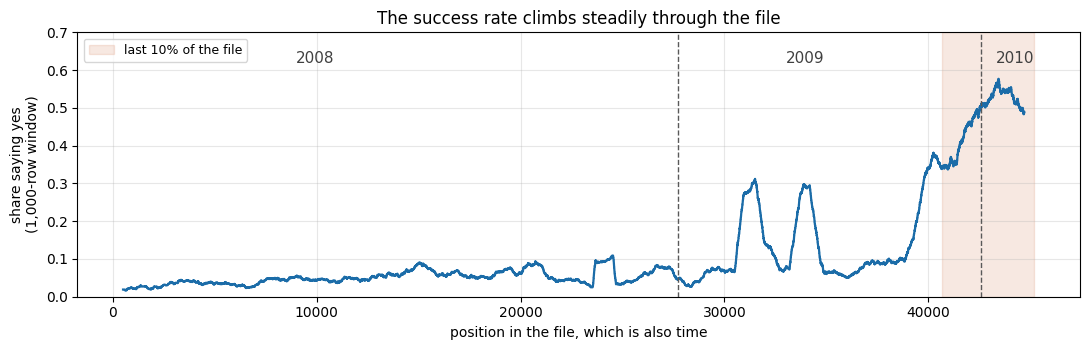

In [33]:
rolling_rate = pd.Series((data["y"] == "yes").astype(float)).rolling(1000, center=True).mean()

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(rolling_rate.index, rolling_rate.values, color="#1b6ca8", lw=1.6)
for boundary in (np.where(steps < -6)[0] + 1):
    ax.axvline(boundary, color="0.35", ls="--", lw=1)
ax.axvspan(0.9 * len(data), len(data), color="#c1440e", alpha=0.12,
           label="last 10% of the file")
for year, position in zip([2008, 2009, 2010], [9000, 33000, 43300]):
    ax.text(position, 0.62, str(year), fontsize=11, color="0.25")
ax.set_xlabel("position in the file, which is also time")
ax.set_ylabel("share saying yes\n(1,000-row window)")
ax.set_ylim(0, 0.7)
ax.grid(alpha=0.3)
ax.legend(loc="upper left", fontsize=9)
ax.set_title("The success rate climbs steadily through the file")
plt.tight_layout()
plt.show()

<div align="center">

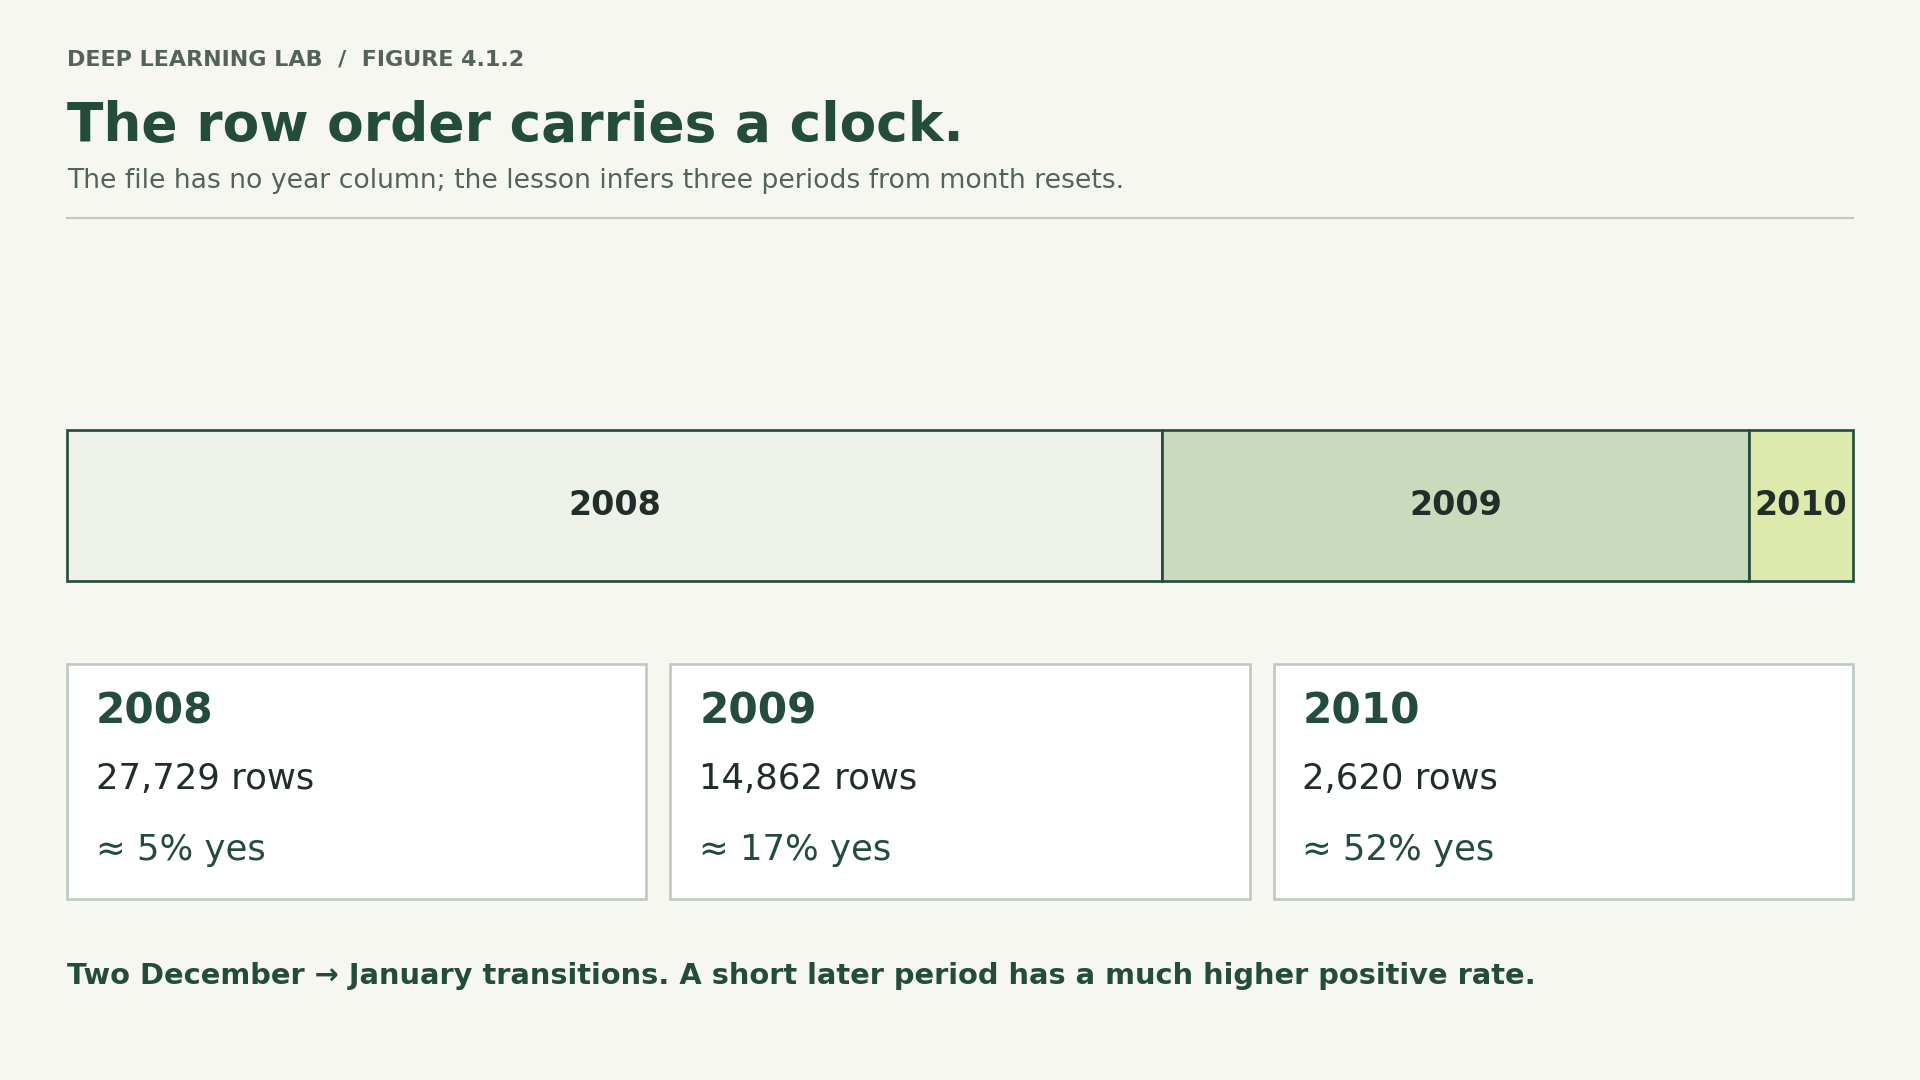

<p><b>Figure 4.1.2.</b> Year-sized segments are proportional to the row counts reported in the lesson. The percentages are its rounded rates, not predictions.</p>

</div>

**Questions to sit with**

1. We counted backward steps of *any* size as well as big ones. Why was the small number worth printing?
2. 2010 has the fewest rows and by far the highest success rate. Give two business explanations, and say what extra data would tell them apart.

<a id="s7"></a>
## 7. Two ways to split the same rows

Here is the consequence of Section 6, and it is the heart of the note.

A **stratified** split picks rows at random, so 2010 rows land in the training set and 2008 rows land in the test set, all mixed together. That answers a real question:

> *How well does this model score a random customer from somewhere in 2008 to 2010?*

But the bank's question is different:

> *We trained on everything up to today. How well will this model do on next month's campaign?*

The split that answers **that** question is the **chronological** one: earliest 80% of rows to train on, the next 10% to validate, the last 10% to test. Train on the past, test on the future, exactly as it will happen in use.

```text
stratified split                 chronological split

 2008 2009 2010                  2008        2009   2010
 ▓░▓░▓▒░▓░▒▓░▒▓                  ▓▓▓▓▓▓▓▓▓▓▓▓▒▒▒▒▒▒ ░░░
 mixed everywhere                train ──────► val ─► test
```

Same file, same model, same preprocessing code. Only the choice of rows changes.

First, a small helper so the two runs are identical in every other way. It fits the preprocessor on the training rows, fits a logistic regression on them, and scores the test rows.

In [34]:
from sklearn.metrics import average_precision_score

def fit_and_score(X, y, split, extra_columns=None):
    """Fit on the training rows, score the test rows. Returns a summary and the predictions."""
    pre = build_preprocessor(X).fit(X.iloc[split["train"]])
    train_inputs = pre.transform(X.iloc[split["train"]])
    test_inputs = pre.transform(X.iloc[split["test"]])

    if extra_columns is not None:                       # used in Section 9
        train_inputs = np.hstack([train_inputs, extra_columns["train"]])
        test_inputs = np.hstack([test_inputs, extra_columns["test"]])

    model = LogisticRegression(max_iter=3000).fit(train_inputs, y[split["train"]])
    predictions = model.predict_proba(test_inputs)[:, 1]
    y_test = y[split["test"]]
    return {
        "test AUC": roc_auc_score(y_test, predictions),
        "test PR-AUC": average_precision_score(y_test, predictions),
        "share who said yes, training rows": float(y[split["train"]].mean()),
        "share who said yes, test rows": float(y_test.mean()),
        "average prediction": float(predictions.mean()),
    }, predictions

stratified_split = make_split(y, "stratified", seed=SEED)
chronological_split = make_split(y, "chronological")

print(check_split(chronological_split, y, "chronological").to_string())

          rows  share of file  share who said yes
train  36169.0            0.8              0.0673
val     4521.0            0.1              0.1608
test    4521.0            0.1              0.4709


Look at that table before running anything else. The chronological training rows are 6.7% yes and the chronological test rows are **47.1%** yes. The model is about to be trained in one world and tested in another.

In [35]:
results = {}
predictions = {}
results["stratified"], predictions["stratified"] = fit_and_score(X, y, stratified_split)
results["chronological"], predictions["chronological"] = fit_and_score(X, y, chronological_split)

comparison = pd.DataFrame(results).T
print(comparison.round(4).to_string())

               test AUC  test PR-AUC  share who said yes, training rows  share who said yes, test rows  average prediction
stratified       0.7796       0.4331                             0.1170                         0.1170              0.1153
chronological    0.6108       0.5531                             0.0673                         0.4709              0.2434


**Test AUC falls from 0.7796 to 0.6108.** The same model, the same columns, the same code; only the choice of which rows to test on. That drop of about 0.17 is far larger than any improvement Day 3 found by tuning anything.

Two more lines in that table are traps, and both are worth knowing by name.

### The PR-AUC trap

**PR-AUC** (average precision) is another way to score a ranking, and it is often recommended for imbalanced problems. Its weakness is that its **floor moves**. A model that guesses at random scores roughly the share of positives in the test set. So:

- on the stratified test set, 11.7% are yes, so random guessing already scores about 0.117;
- on the chronological test set, 47.1% are yes, so random guessing already scores about 0.471.

That is why PR-AUC went *up*, from 0.4331 to 0.5531, while the model actually got worse. Comparing PR-AUC across test sets with different positive rates compares the floors, not the models. Always print the share of positives next to it.

### The calibration trap

**Calibration** asks a different question from AUC. AUC asks "does the model put the right customers at the top of the list?" Calibration asks "when the model says 30%, do 30% of those customers actually say yes?"

The chronological model's average prediction is 0.2434 while the true rate is 0.4709. It learnt from a world where 6.7% said yes, so its probabilities are anchored far too low. Any decision written as "phone everybody the model scores above 0.3" is quietly wrong, and AUC will never tell you.

Neither split is the correct one in general. They answer different questions, and the mistake is using the random split's number to answer the chronological question.

Which means being honest about Days 2 and 3: every Bank Marketing number in this course so far came from a random split. They were fine for what those days were studying, which was how training behaves. They were never an estimate of how this model would do next month.

<div align="center">

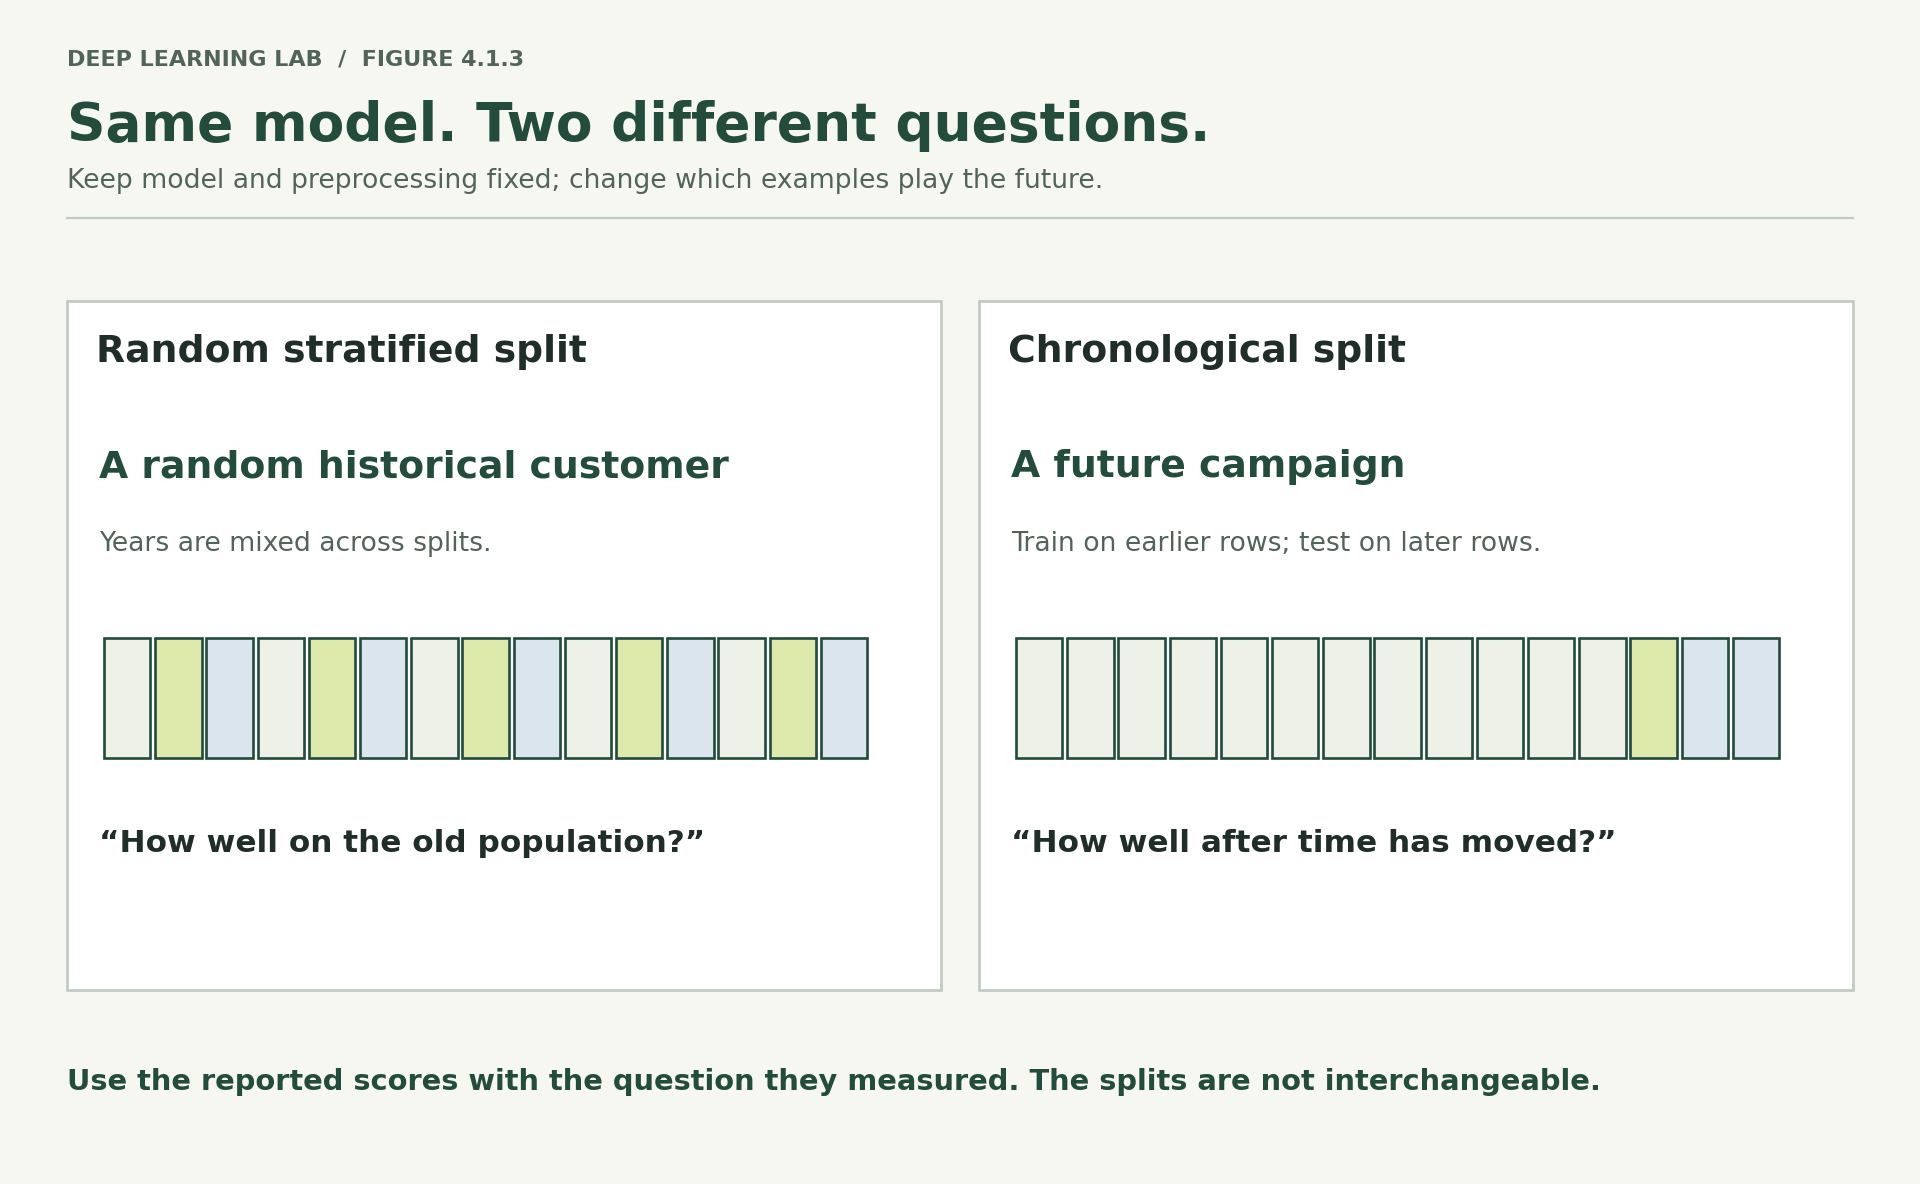

<p><b>Figure 4.1.3.</b> Stratification mixes time periods; a chronological split preserves them. Both can be valid, but they answer different deployment questions.</p>

</div>

**Questions to sit with**

1. Write one sentence for each split saying what question it answers.
2. Why can PR-AUC rise while the model gets worse? What would you print beside it to stop the confusion?
3. The chronological model's probabilities are far too low. Would re-training on all three years fix that for 2011? Why or why not?

<a id="s8"></a>
## 8. What changed between the two periods

"The data changed" is not a diagnosis. Two different things can change, and they break a model in different ways, so they have names.

- **Label shift** — the answer becomes more or less common. Here the yes rate goes from 6.7% in the training rows to 47.1% in the test rows. This is what breaks calibration.
- **Covariate shift** — the *inputs* change. Different kinds of customer are being phoned. This breaks the model in places it has barely seen.

Take them one at a time. Label shift is already measured, so start with the inputs.

For each column we want a single number saying "how different are these two periods?". Numeric and categorical columns need different measures.

**For a numeric column**: how far apart are the two averages, measured in standard deviations? Dividing by the spread makes ages and balances comparable.

**For a categorical column**: what share of rows would have to change category to make the two periods look the same? Add up the differences in each category's share and halve it; the halving is because every row that leaves one category arrives in another, so each difference gets counted twice.

Both, on toy numbers first.

In [36]:
period_a = pd.Series(["cell", "cell", "cell", "phone"])       # 75% cell
period_b = pd.Series(["cell", "phone", "phone", "phone"])     # 25% cell

shares_a = period_a.value_counts(normalize=True)
shares_b = period_b.value_counts(normalize=True)

print("period A shares:", shares_a.to_dict())
print("period B shares:", shares_b.to_dict())
print("difference per category:", shares_a.sub(shares_b, fill_value=0).abs().to_dict())
print("share of rows that moved:", 0.5 * shares_a.sub(shares_b, fill_value=0).abs().sum())

period A shares: {'cell': 0.75, 'phone': 0.25}
period B shares: {'phone': 0.75, 'cell': 0.25}
difference per category: {'cell': 0.5, 'phone': 0.5}
share of rows that moved: 0.5


Half the rows would have to change to line those two up. Now the same measure on every column, comparing the chronological training rows with the chronological test rows.

In [37]:
early = X.iloc[chronological_split["train"]]
late = X.iloc[chronological_split["test"]]

rows = []
for column in X.columns:
    if pd.api.types.is_numeric_dtype(X[column]):
        gap = abs(late[column].mean() - early[column].mean()) / X[column].std()
        rows.append((column, "numeric: gap in averages, in spreads", gap))
    else:
        shares_early = early[column].value_counts(normalize=True)
        shares_late = late[column].value_counts(normalize=True)
        moved = 0.5 * shares_early.sub(shares_late, fill_value=0).abs().sum()
        rows.append((column, "categorical: share of rows that moved", moved))

drift = pd.DataFrame(rows, columns=["column", "measure", "how much it changed"])
print(drift.sort_values("how much it changed", ascending=False).round(3).to_string(index=False))

   column                               measure  how much it changed
    pdays  numeric: gap in averages, in spreads                0.899
 previous  numeric: gap in averages, in spreads                0.728
 poutcome categorical: share of rows that moved                0.482
    month categorical: share of rows that moved                0.454
  housing categorical: share of rows that moved                0.366
 campaign  numeric: gap in averages, in spreads                0.354
      age  numeric: gap in averages, in spreads                0.330
  contact categorical: share of rows that moved                0.297
      job categorical: share of rows that moved                0.268
  balance  numeric: gap in averages, in spreads                0.243
      day  numeric: gap in averages, in spreads                0.143
education categorical: share of rows that moved                0.135
     loan categorical: share of rows that moved                0.121
  marital categorical: share of ro

The three biggest movers are `pdays`, `previous` and `poutcome`. All three describe the **same thing**: whether this customer had been contacted in an earlier campaign.

In [38]:
print(f"had been contacted before: early period {(early['pdays'] > -1).mean():.3f}"
      f"  ->  late period {(late['pdays'] > -1).mean():.3f}")
print(f"contact type 'unknown'   : early period {(early['contact'] == 'unknown').mean():.3f}"
      f"  ->  late period {(late['contact'] == 'unknown').mean():.3f}")
print(f"average age              : early period {early['age'].mean():.1f}"
      f"        ->  late period {late['age'].mean():.1f}")

had been contacted before: early period 0.106  ->  late period 0.589
contact type 'unknown'   : early period 0.353  ->  late period 0.056
average age              : early period 40.8        ->  late period 44.3


In the early period about one customer in ten had been phoned before. In the late period it is nearly six in ten. The bank stopped cold-calling strangers and started calling back people it already knew, who are much likelier to say yes. That single change explains both the label shift and most of the covariate shift.

### Checking for shift without knowing where to look

The table above can only see one column at a time. Shift can also hide in *combinations*: each column looks normal, but the mixture is different.

There is a neat trick for that, called **adversarial validation**. The idea:

1. forget the real label completely;
2. label every early row `0` and every late row `1`;
3. train a model to tell them apart;
4. see how well it does.

If it cannot tell them apart, the two periods look alike and your split is safe. If it can, they are different, and the score tells you how different.

We need one more tool to do this honestly: **cross-validation**. Rather than a single split, `cross_val_predict` cuts the data into 5 parts, trains on 4 and predicts the 5th, five times over, so every row gets a prediction from a model that never saw it.

The last argument, `class_weight="balanced"`, matters because the late period has far fewer rows than the early one; it tells the model to treat the two groups as equally important.

In [39]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline

def adversarial_auc(columns):
    """How well can a model tell the early rows from the late rows?"""
    both = pd.concat([early[columns], late[columns]])
    is_late = np.concatenate([np.zeros(len(early)), np.ones(len(late))])
    detector = make_pipeline(build_preprocessor(both),
                             LogisticRegression(max_iter=3000, class_weight="balanced"))
    predicted = cross_val_predict(detector, both, is_late, method="predict_proba",
                                  cv=StratifiedKFold(5, shuffle=True, random_state=0))[:, 1]
    return roc_auc_score(is_late, predicted)

all_columns = list(X.columns)
without_calendar = [c for c in all_columns if c not in ("month", "day")]

print(f"can a model tell the periods apart? AUC {adversarial_auc(all_columns):.4f}")
print(f"same, with month and day removed  : AUC {adversarial_auc(without_calendar):.4f}")

can a model tell the periods apart? AUC 0.9383


same, with month and day removed  : AUC 0.9030


Remember what AUC means here. 0.5 would mean the two periods are indistinguishable. We get **0.9383**, so a simple model can nearly always tell which period a customer came from.

Removing `month` and `day` barely changes it (0.9030), which rules out the easy explanation that this is just seasonality. The customers themselves are different.

This check is worth running before you trust any split, and again in production against live traffic, where it becomes a drift alarm. Day 9 and the GenAI module return to monitoring.

**Questions to sit with**

1. Give one example each of label shift and covariate shift from work you have seen.
2. An adversarial AUC of 0.5 between your training and test sets: good or bad? What if it is 0.5 between your training data and last week's live traffic?
3. The biggest movers all describe previous contact. What would you ask the marketing team?

<a id="s9"></a>
## 9. Group leakage: the calendar day

Two kinds of leak so far: through a row (the same row on both sides) and through time (the future mixed into the past). The third is quieter.

A **group** is a set of rows that belong together and are more alike than two random rows would be. Several patients from one hospital. Several photos of one person. Several reviews by one author. Several sentences from one document.

Group leakage happens when rows from the same group land on both sides of a split. The model can then do well on test rows by recognising the *group*, which will not be there in real use.

Bank Marketing has a natural group that is easy to miss: **the calendar day**. Calls made on the same day share a team, a script, an offer and the mood of the market.

In [40]:
data["date_key"] = data["year"].astype(str) + "-" + data["month"] + "-" + data["day"].astype(str)
dates = data["date_key"].to_numpy()

per_day = pd.DataFrame({"date": dates, "said_yes": y}).groupby("date")["said_yes"].agg(["size", "mean"])

print(f"number of distinct calling days : {len(per_day)}")
print(f"calls per day                   : median {per_day['size'].median():.0f}, biggest {per_day['size'].max()}")
print(f"success rate on a day           : 10th percentile {per_day['mean'].quantile(.1):.3f}, "
      f"median {per_day['mean'].median():.3f}, 90th percentile {per_day['mean'].quantile(.9):.3f}")

number of distinct calling days : 561
calls per day                   : median 15, biggest 825
success rate on a day           : 10th percentile 0.000, median 0.348, 90th percentile 0.727


Some days nobody says yes. On other days nearly three quarters do. Knowing **which day** a call happened tells you a great deal about how it went.

A practitioner who notices that will be tempted to build a column out of it: the average success rate of that day. And they will be careful about it, computing the average from **training rows only**, which sounds exactly like the rule from Section 5.

Build that column and look at it.

In [41]:
def day_rate_feature(split, dates, y):
    """For each row, the success rate of its calling day, measured on training rows only."""
    train_rows = split["train"]
    rate_per_day = pd.Series(y[train_rows]).groupby(dates[train_rows]).mean()
    fallback = float(y[train_rows].mean())      # for a day we have never seen
    return {part: pd.Series(dates[rows]).map(rate_per_day).fillna(fallback)
                            .to_numpy()[:, None].astype(np.float32)
            for part, rows in split.items()}

demo_feature = day_rate_feature(stratified_split, dates, y)
print("the new column, for the first five test rows:")
print(np.round(demo_feature["test"][:5].ravel(), 3))
print()
print("their actual days:", dates[stratified_split['test'][:5]])

the new column, for the first five test rows:
[0.591 0.063 0.087 0.068 0.091]

their actual days: ['2010-aug-5' '2009-may-7' '2009-may-18' '2009-feb-6' '2009-apr-16']


Now the experiment. We train with and without that column, under two different splitting rules:

- **stratified** — random rows, so a test row's day is almost always a day that also appears in training;
- **group** — whole days are held out, so every test day is one the model has never seen.

Three different seeds each, because the group split varies more from run to run.

In [42]:
comparison_rows = []
for seed in [0, 1, 2]:
    for policy in ["stratified", "group"]:
        this_split = make_split(y, policy, seed=seed, groups=dates)
        without, _ = fit_and_score(X, y, this_split)
        with_day, _ = fit_and_score(X, y, this_split,
                                    extra_columns=day_rate_feature(this_split, dates, y))
        comparison_rows.append({"seed": seed, "split": policy,
                                "test rows": len(this_split["test"]),
                                "without day column": without["test AUC"],
                                "with day column": with_day["test AUC"]})

group_test = pd.DataFrame(comparison_rows)
print(group_test.round(4).to_string(index=False))
print()
print(group_test.groupby("split")[["without day column", "with day column"]]
      .agg(["mean", "std"]).round(4).to_string())

 seed      split  test rows  without day column  with day column
    0 stratified       4522              0.7586           0.7984
    0      group       4167              0.7914           0.7356
    1 stratified       4522              0.7742           0.8226
    1      group       3131              0.7970           0.7279
    2 stratified       4522              0.7566           0.7997
    2      group       4026              0.7499           0.7144

           without day column         with day column        
                         mean     std            mean     std
split                                                        
group                  0.7794  0.0257          0.7259  0.0107
stratified             0.7631  0.0096          0.8069  0.0136


Read the averages slowly, because this is the whole point of the section.

**Without the day column**, the two splitting rules broadly agree: 0.7631 stratified against 0.7794 group. The group split bounces around more from seed to seed (standard deviation 0.0257 against 0.0096), and that gap is inside its own bouncing. So this model does not depend on sharing days.

**With the day column**, the stratified split reports **0.8069**, a gain of about 0.04. It looks like a good new feature. The group split reports **0.7259**, which is about 0.05 *worse* than having no day column at all. The distance between those two numbers, roughly 0.08 AUC, is the size of the leak.

Here is the mechanism, step by step:

1. on a random split, a test call's day is nearly always a day that is also in the training set;
2. the day's average success rate was computed from the other calls made that day — the test row's **neighbours**, whose answers we know;
3. so the column hands each test row a summary of its own neighbours' answers;
4. in real use, every day is a new day, the column falls back to the overall average for every row, and the model has learnt to lean on a column that is now the same everywhere.

No row was ever on both sides. The encoder was fitted on training rows only. The leak travelled through the group.

This pattern is everywhere once you look: several rows per customer, per patient, per household, per device, per session; several crops from one image; several chunks from one document. Day 8 meets it again in fine-tuning data.

**Questions to sit with**

1. The day column was built from training rows only, and it still leaked. Where exactly did the test information come from?
2. Name the group you would split on for: hospital readmission; product reviews; a model trained on frames cut from videos.
3. Why is a group split's score noisier from seed to seed than a stratified split's?

<a id="s10"></a>
## 10. The 11.7% problem

Back to the stratified split for the last measurement. Only 11.7% of customers said yes, which makes this an **imbalanced** problem, and imbalance breaks the most natural score of all.

In [43]:
y_test = y[stratified_split["test"]]

y_train = y[stratified_split["train"]]

print(f"positive examples in the training rows: {int(y_train.sum()):,} out of {len(y_train):,}")
print(f"share of test customers who said yes : {y_test.mean():.4f}")
print(f"a model that always says 'no' scores  : {1 - y_test.mean():.4f} accuracy")
print(f"...and finds {0} of the {int(y_test.sum())} customers who would have said yes")

positive examples in the training rows: 4,231 out of 36,168
share of test customers who said yes : 0.1170
a model that always says 'no' scores  : 0.8830 accuracy
...and finds 0 of the 529 customers who would have said yes


88.3% accuracy for a model that has learnt nothing. This is why Day 3 always printed the majority-class rate beside accuracy.

The usual reflex is to "fix" the imbalance by making the rare class count for more. In scikit-learn that is `class_weight="balanced"`, which weights each class by how rare it is. In PyTorch it is `pos_weight` inside `BCEWithLogitsLoss`. Same idea: mistakes on the rare class hurt more.

Before running it, let us be precise about the words used to judge these models. Suppose we phone everybody the model scores above some cut-off:

- **precision** — of the customers we phoned, what share said yes;
- **recall** — of all the customers who would have said yes, what share we managed to phone;
- **threshold** — the cut-off itself, 0.5 by default, which is a choice and not a law;
- **Brier score** — the average squared distance between the predicted probability and what happened. Lower is better, and unlike AUC it punishes probabilities that are the wrong size rather than in the wrong order.

Now measure what re-weighting actually changes.

In [44]:
from sklearn.metrics import brier_score_loss

pre = build_preprocessor(X).fit(X.iloc[stratified_split["train"]])
train_inputs = pre.transform(X.iloc[stratified_split["train"]])
test_inputs = pre.transform(X.iloc[stratified_split["test"]])

scores = {}
probabilities = {}
for label, weighting in [("plain", None), ("balanced weights", "balanced")]:
    model = LogisticRegression(max_iter=3000, class_weight=weighting).fit(
        train_inputs, y[stratified_split["train"]])
    p = model.predict_proba(test_inputs)[:, 1]
    probabilities[label] = p
    phoned = p > 0.5
    scores[label] = {
        "test AUC": roc_auc_score(y_test, p),
        "average prediction": p.mean(),
        "share phoned at 0.5": phoned.mean(),
        "recall at 0.5": phoned[y_test == 1].mean(),
        "precision at 0.5": y_test[phoned].mean(),
        "Brier score": brier_score_loss(y_test, p),
    }

print(pd.DataFrame(scores).round(4).to_string())

                      plain  balanced weights
test AUC             0.7796            0.7795
average prediction   0.1153            0.4124
share phoned at 0.5  0.0299            0.2663
recall at 0.5        0.1815            0.6181
precision at 0.5     0.7111            0.2716
Brier score          0.0840            0.1801


Go line by line, because the result is easy to misread.

**AUC barely moved**: 0.7796 against 0.7795. The ordering of customers is essentially unchanged. Re-weighting was never going to make the model better at telling a yes from a no, and AUC is the measure of exactly that.

**The size of the predictions changed completely**: the average prediction went from 0.1153, which is close to the true rate of 0.1170, to 0.4124, which is nowhere near it.

**So the 0.5 threshold now means something different.** The weighted model phones 26.6% of customers instead of 3.0%. Recall rises from 0.18 to 0.62 and precision falls from 0.71 to 0.27. Those look like large changes, and they are, but they came from moving the cut-off, not from a better model.

**The Brier score more than doubled**, from 0.0840 to 0.1801, because the probabilities are now the wrong size.

The decision that matters is the threshold, and it should come from the business, not from 0.5. Suppose the call centre can phone 10% of the list.

In [45]:
budget = 0.10
for label, p in probabilities.items():
    cut_off = np.quantile(p, 1 - budget)
    phoned = p >= cut_off
    print(f"{label:<17} phone the top {budget:.0%}: "
          f"precision {y_test[phoned].mean():.4f}, recall {phoned[y_test == 1].mean():.4f}")

plain             phone the top 10%: precision 0.4923, recall 0.4216
balanced weights  phone the top 10%: precision 0.4967, recall 0.4253


With a fixed calling budget the two models phone almost exactly the same customers and get almost the same results (precision 0.4923 against 0.4967). The re-weighting bought nothing.

Last, see the calibration damage directly. We sort customers into ten equal groups by predicted score — these are **deciles** — and compare what each model predicted with what actually happened.

In [46]:
deciles = pd.qcut(probabilities["plain"], 10, labels=False)
calibration = pd.DataFrame({
    "decile": deciles,
    "predicted, plain": probabilities["plain"],
    "predicted, balanced": probabilities["balanced weights"],
    "actually said yes": y_test,
}).groupby("decile").mean()

print(calibration.round(3).to_string())

        predicted, plain  predicted, balanced  actually said yes
decile                                                          
0                  0.020                0.143              0.026
1                  0.031                0.207              0.029
2                  0.047                0.274              0.035
3                  0.062                0.329              0.062
4                  0.075                0.373              0.073
5                  0.089                0.415              0.077
6                  0.105                0.461              0.091
7                  0.125                0.508              0.117
8                  0.166                0.588              0.166
9                  0.433                0.826              0.492


The plain model tracks reality closely: its predictions and the real rate rise together, decile by decile. The balanced model is inflated everywhere, by roughly five times through the middle of the range — 0.415 predicted against 0.077 actual in decile 5.

So when *is* re-weighting worth it? When the positive class is so rare that the model barely sees it and fails to rank positives at all — a problem you detect with AUC and PR-AUC, not with accuracy. Here the training set contains 4,231 positive examples, which is plenty.

What to report for an imbalanced problem:

- **AUC** for the quality of the ranking;
- **PR-AUC next to the share of positives**, so the reader knows the floor;
- **precision and recall at the threshold you will really use**;
- a **calibration check** if anybody is going to read the probabilities as probabilities.

**Questions to sit with**

1. Balanced weights lifted recall at 0.5 from 0.18 to 0.62. Why is it misleading to call that an improvement?
2. How would you pick a threshold if missing a subscriber costs ten times as much as a wasted phone call?
3. The chronological test set was 47% yes. Is it still imbalanced? What does that do to the idea of choosing one class-weight setting and keeping it?

<a id="s11"></a>
## 11. Writing the decision down

A split is a decision, and decisions get written down so that the next person — including you in three months — knows what was chosen and why.

First, the four rules side by side, so the differences are visible in one place.

In [47]:
summary = {}
for policy in ["stratified", "random", "chronological", "group"]:
    this_split = make_split(y, policy, seed=SEED, groups=dates)
    summary[policy] = check_split(this_split, y, policy)["share who said yes"]

print("share who said yes, by part and by rule:")
print(pd.DataFrame(summary).T.to_string())

share who said yes, by part and by rule:
                train     val    test
stratified     0.1170  0.1170  0.1170
random         0.1161  0.1146  0.1267
chronological  0.0673  0.1608  0.4709
group          0.1270  0.0858  0.0976


The stratified and random rules give three nearly identical parts. The group rule gives parts that wobble, because whole days move together. The chronological rule gives three completely different worlds, which is the honest picture of what this data is.

A **data card** is a short note kept beside the dataset recording what is in it, what is wrong with it, and the decisions taken. Ours:

In [48]:
data_card = """# Data card: UCI Bank Marketing (bank-full.csv) - Day 4

Rows 45,211 | 15 input columns after dropping `duration` | label: subscribed, 11.7% yes
The rows are in date order, May 2008 to November 2010. `year` is inferred from the
month sequence and is never used as a model input.

## Known quirks
- pdays = -1 means "never contacted before" (81.7% of rows); poutcome = "unknown"
  records the same fact on the same rows, apart from 5
- contact = "unknown" (28.8%) predicts the label (4.1% yes against 14.9% on mobile):
  keep it as its own category, do not fill it in
- balance is negative on 8.3% of rows: valid, it is an overdraft
- default is one value on 98.2% of rows: nearly no information
- no duplicate rows

## Leakage risks
- duration: known only once the call has ended. Dropped. (Note 3.4 Case 6)
- calendar day: rows cluster by day, so any day-level summary column leaks across a
  row-level split. Measured here at about 0.08 AUC.
- time: the yes rate rises about tenfold across the file, so a random split mixes the
  future into the training rows.

## Split policy for Day 4
- stratified 80/10/10, seed 42: keeps continuity with every Day 2 and Day 3 number.
  Answers "how well on a random customer from 2008-2010?"
- chronological 80/10/10: the deployment check.
  Answers "how well on next month's campaign?"
- report both whenever a model is being judged.

## Reporting rules
- always print the share of positives next to PR-AUC
- choose the decision threshold from calling capacity, not from 0.5
- check calibration before anybody reads a prediction as a probability
"""

with open("results/data_card_bank_marketing.md", "w") as f:
    f.write(data_card)

print(data_card)

# Data card: UCI Bank Marketing (bank-full.csv) - Day 4

Rows 45,211 | 15 input columns after dropping `duration` | label: subscribed, 11.7% yes
The rows are in date order, May 2008 to November 2010. `year` is inferred from the
month sequence and is never used as a model input.

## Known quirks
- pdays = -1 means "never contacted before" (81.7% of rows); poutcome = "unknown"
  records the same fact on the same rows, apart from 5
- contact = "unknown" (28.8%) predicts the label (4.1% yes against 14.9% on mobile):
  keep it as its own category, do not fill it in
- balance is negative on 8.3% of rows: valid, it is an overdraft
- default is one value on 98.2% of rows: nearly no information
- no duplicate rows

## Leakage risks
- duration: known only once the call has ended. Dropped. (Note 3.4 Case 6)
- calendar day: rows cluster by day, so any day-level summary column leaks across a
  row-level split. Measured here at about 0.08 AUC.
- time: the yes rate rises about tenfold across the file

### What to take away

**A split is a claim about the future.** Decide it by asking who and when the model will be used on, then check that the data can support the claim.

**Audit before you model.** Sentinel numbers, placeholder words and near-constant columns all sail past `isna()`. Run the audit on the raw table, because encoding hides the evidence.

**Leaks come in three shapes, and this note measured all three.**

```text
through a row    same row in train and test        Note 3.4 Case 4: AUC went to 1.0000
through time     future mixed into the past        0.7796 on a random split, 0.6108 on a chronological one
through a group  same day in train and test        day column: 0.8069 random, 0.7259 by day
```

**Not every leak is expensive, and you still close them all.** The pre-split scaler was worth +0.000093 here. The same mistake with a label-reading step was worth about 0.08. You cannot tell in advance which kind you have.

**"The data changed" needs a diagnosis.** Label shift breaks the size of your probabilities. Covariate shift breaks the model where it has little experience. Adversarial validation finds both before you have trained anything.

**Re-weighting moves the threshold, not the ranking.** Pick the threshold from the real constraint, and report PR-AUC beside the positive rate that sets its floor.

The finished pipeline, which every later note in Day 4 assumes:

```text
raw file
   ↓
drop columns you would not have at prediction time
   ↓
audit: sentinels, placeholders, duplicates
   ↓
choose a split rule, and say what question it answers
   ↓
check the split, and stop if it is broken
   ↓
fit preprocessing on training rows only
   ↓
transform every part with that same fitted object
   ↓
train, and score on rows nobody tuned against
```

### Transition to Note 4.2

You can now trust the data going into an experiment, and the rows coming out of a split. What you cannot yet do is trust the **record** of an experiment.

In Note 4.2 you run the same model again and ask harder questions about it. Does running it twice give the same answer, to the last decimal? What has to be saved so that somebody else can reproduce your number six months from now? What exactly does a checkpoint need to hold so a run can be interrupted and resumed without changing the result? And how large is the difference between two runs that changed nothing at all — because until you know that number, you cannot say whether a change to your model helped.